# Week 4 Lab: Train a diffusion model, then use Stable Diffusion

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 2, 3, 4

Part A — build it yourself:
1. implement the **forward (noising) process** in closed form;
2. train a **DDPM** on 2-D data and a tiny **U-Net DDPM** on MNIST, and write the **sampling loop**;
3. write a **DDIM** sampler that needs 20× fewer steps.

Part B — use a pretrained model (Hugging Face **Diffusers**):
4. generate images with **Stable Diffusion 1.5**; sweep **steps, guidance scale, seeds**; try **negative prompts** and **schedulers**;
5. compare with the distilled **SD-Turbo** (1–4 steps) and measure time;
6. evaluate prompt alignment with a **CLIP score** you implement.

**Runtime:** Colab → Runtime ▸ Change runtime type ▸ **T4 GPU**. Part A also runs on a CPU (slower); Part B needs a GPU for Stable Diffusion (on CPU the notebook falls back to SD-Turbo). On a laptop CPU the complete notebook took about 17 minutes.

**Licence note:** Stable Diffusion 1.5 is released under the CreativeML OpenRAIL-M licence, which forbids certain uses (e.g. generating content to harass or deceive). Do not generate images of real, identifiable people. Keep the built-in safety checker on.

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **GPU** if available. A T4 is sufficient for the GPU examples. Free GPU access varies. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. Read this week's runtime note. Model downloads and training can take longer on CPU, and some full experiments need a GPU.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete before running dependent cells. Questions marked ✍️ need a short written answer.
> - Read each diagram by following its numbered blocks. The solid arrows carry data to the next block. A dashed arrow shows a step that repeats.

## This week's place in the course

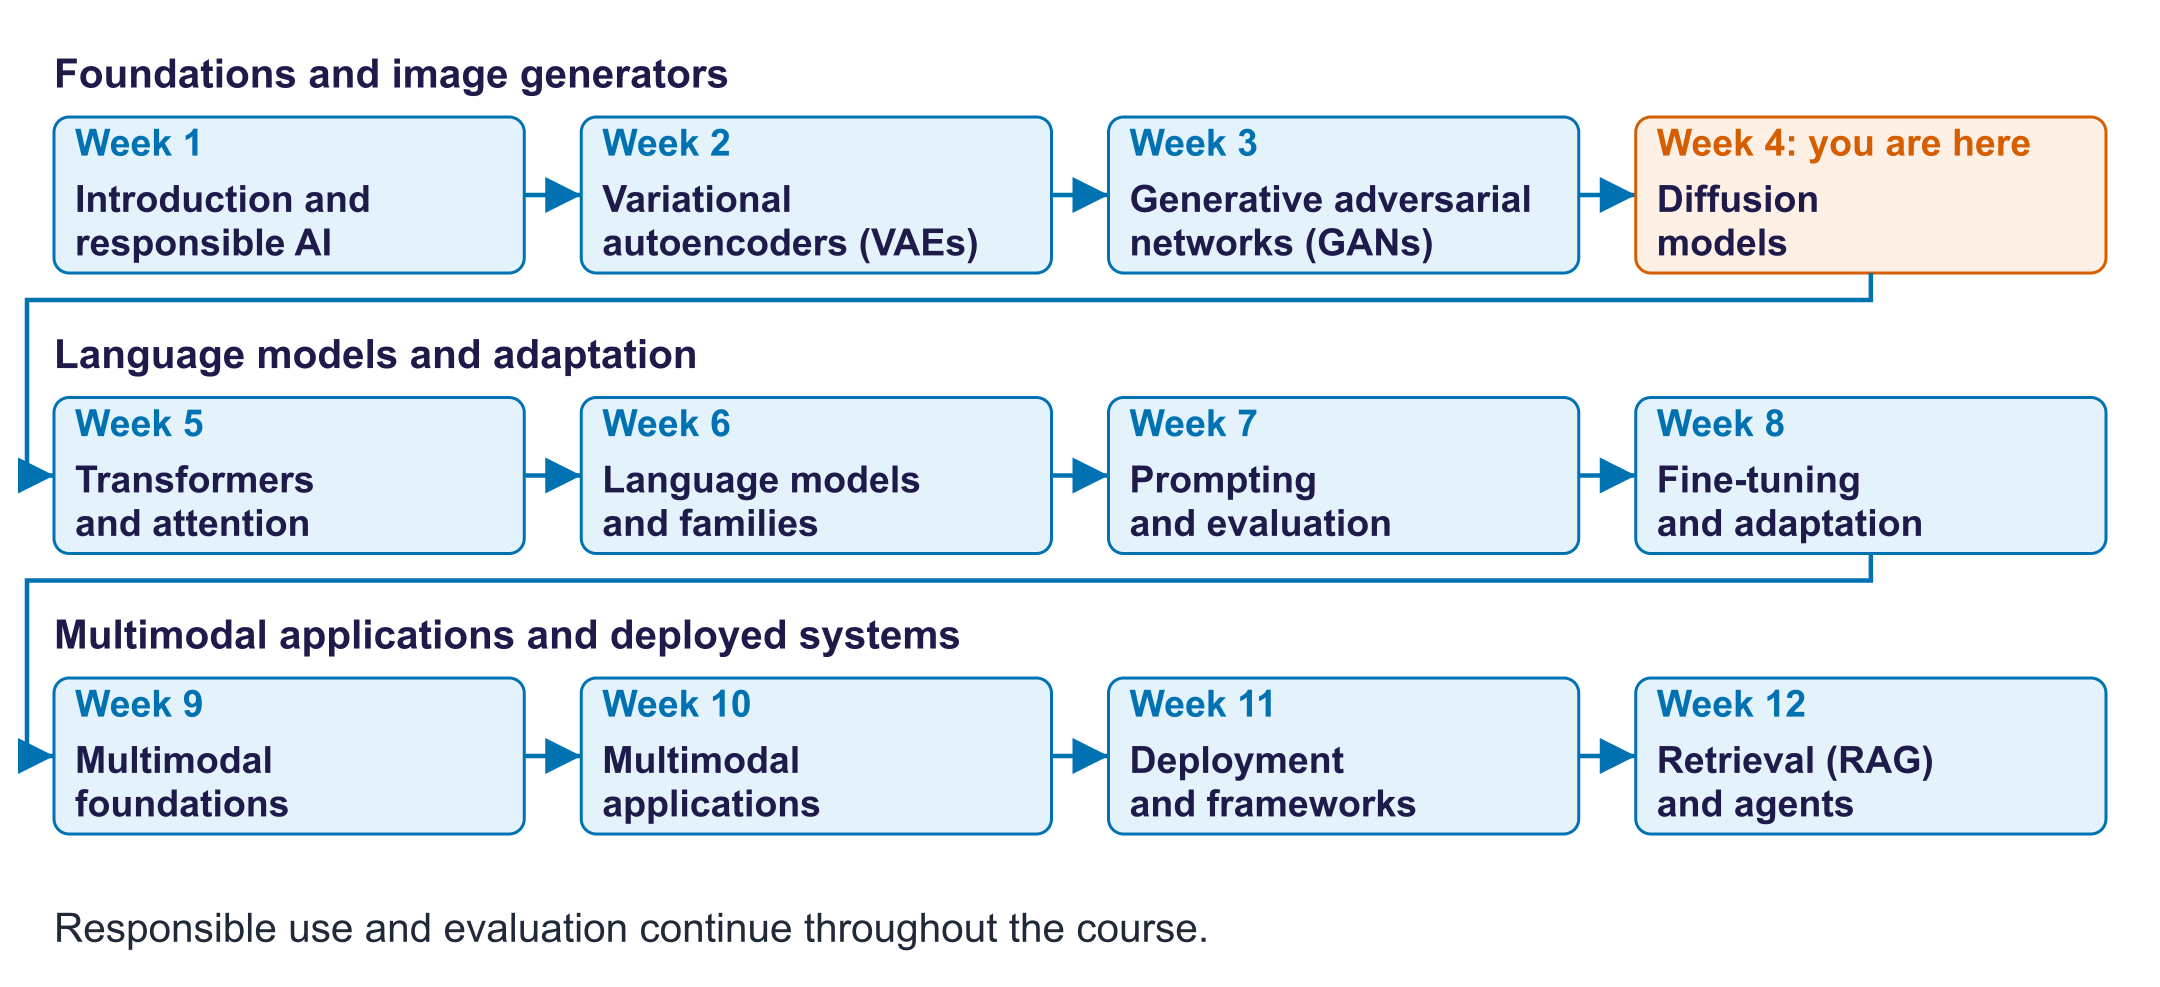

## Before coding: training and generation use different loops

Training corrupts known data and teaches a network to predict the added noise.
Generation starts from new noise and reuses that network at decreasing noise
levels. The **denoiser** learns; the **sampler** decides how each state changes.

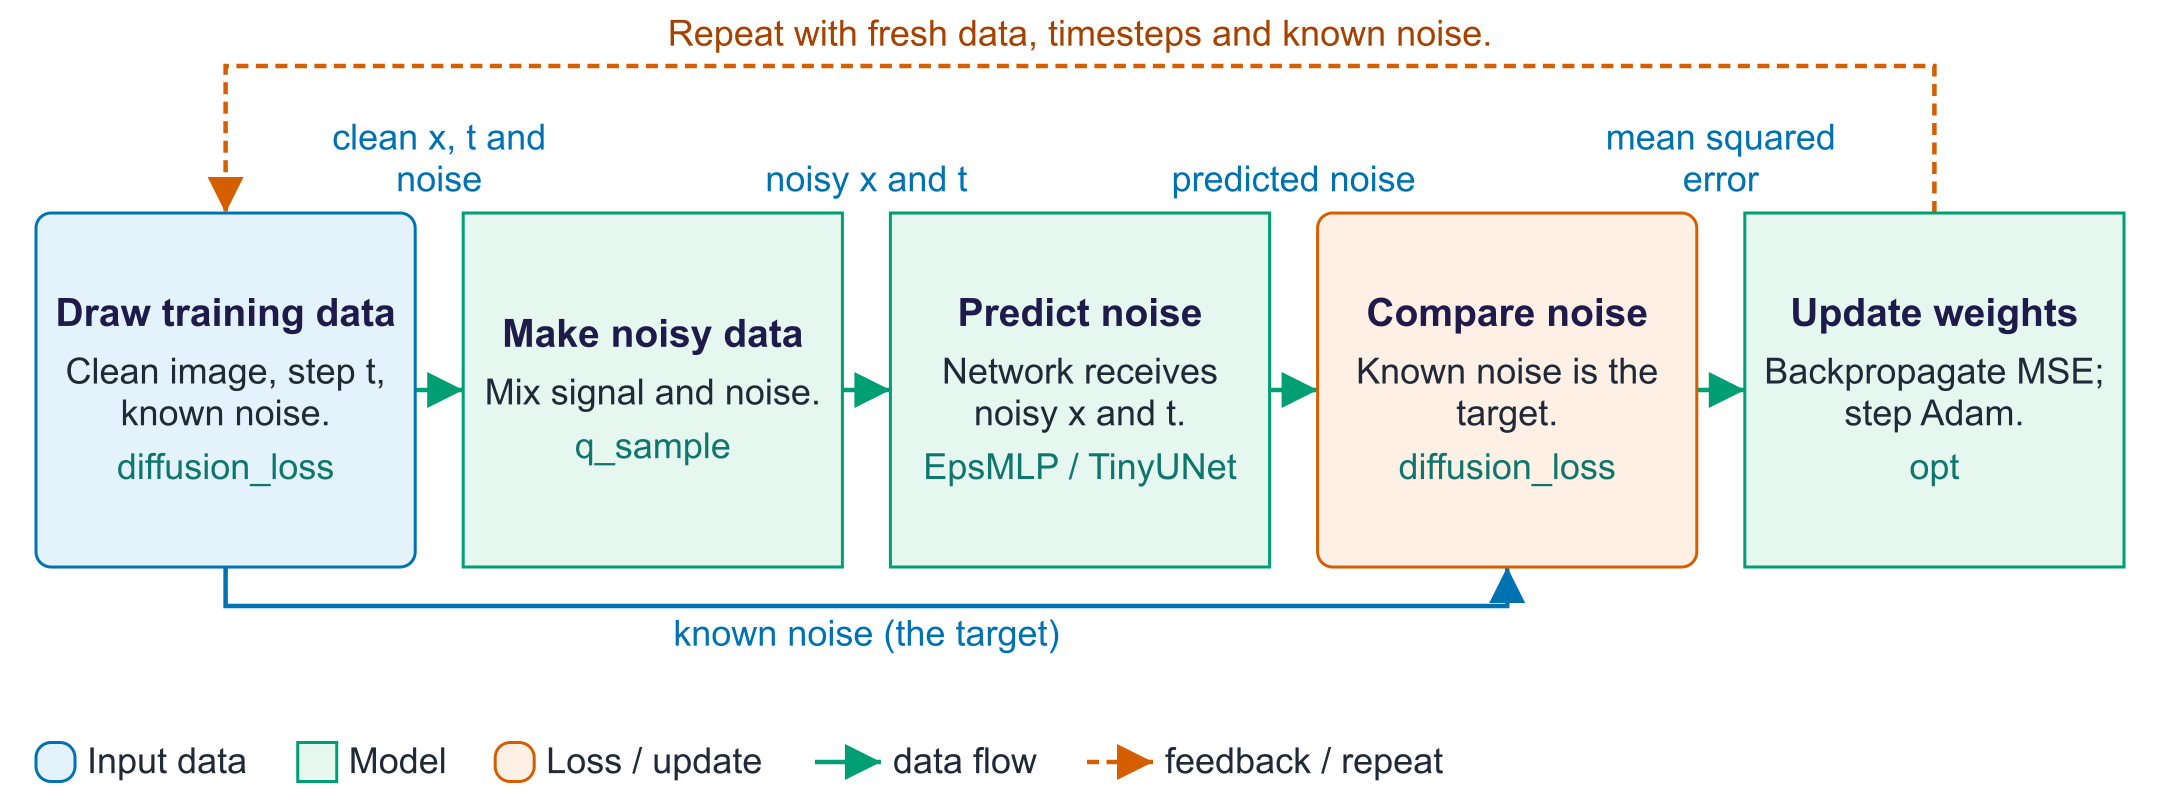

Follow `diffusion_loss` → `q_sample` → `EpsMLP` or `TinyUNet` → the noise
comparison → `opt.step`. The sampled noise is a separate target input to the
loss, not an input to the network. Only the denoiser weights are updated.

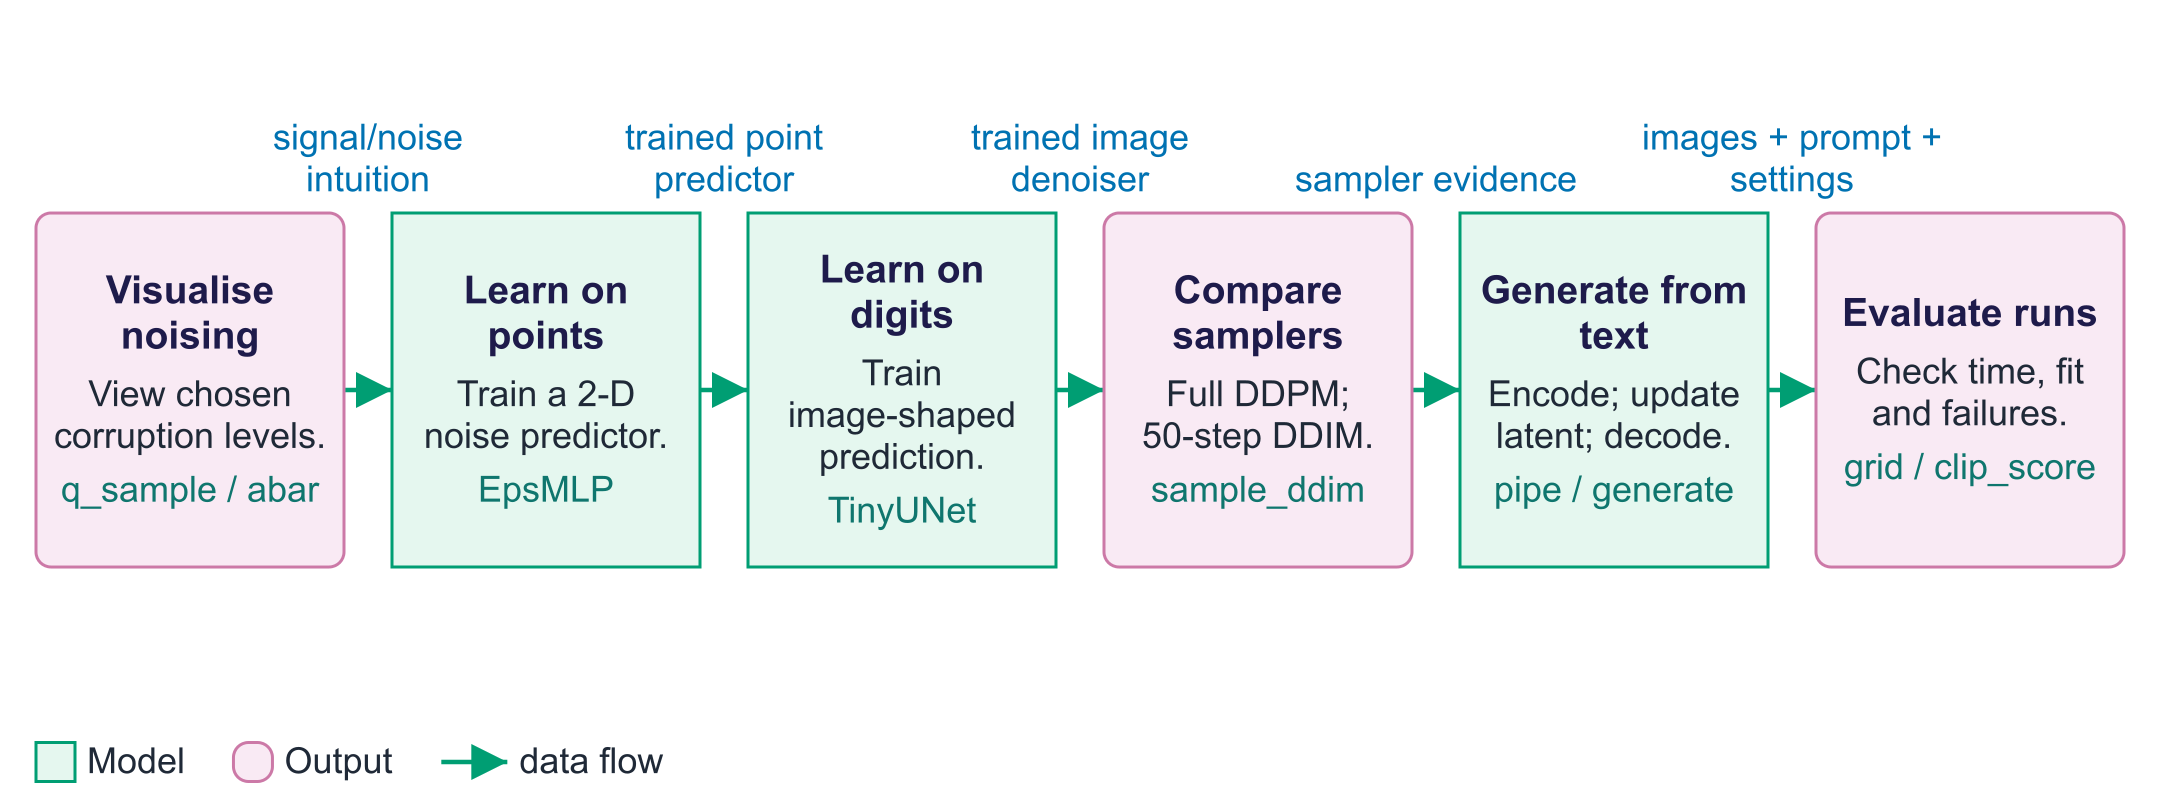

| Diagram block | Code to find | First observation |
|---|---|---|
| Visualise noising | `q_sample`, `abar` | Larger timestep indices usually retain less signal. |
| Learn on points | `EpsMLP`, `diffusion_loss` | The network predicts two noise values per point. |
| Learn on digits | `TinyUNet` | Predicted noise has the same shape as the image batch. |
| Compare samplers | `sample_ddpm`, `sample_ddim` | DDIM selects timesteps across the full schedule. |
| Generate from text | `pipe`, `generate` | A pretrained system adds text encoding and latent decoding. |
| Evaluate controlled runs | `grid`, `clip_score` | Record the active model, controls, timing, and visual evidence. |

**Pause and predict:** does a training target contain the clean image or the
noise that was drawn? Trace the target path before implementing the loss.

## Read, run, change, check

**Read:** begin with one clean digit and the pictures made by adding noise.
**Run:** complete `q_sample`, then the loss and reverse-step TODOs before
training. The same loss is used for points and for digit images.
**Change:** compare DDPM and DDIM using the same trained denoiser. In the
pretrained pipeline, vary one control while keeping the prompt and seed fixed.
**Check:** name the active model and sampler in your evidence table; the
CPU fallback and short test configuration use different pretrained models.

A **denoiser** predicts the noise in an input. A **noise schedule** records
how noisy each step is. A **sampler** uses these predictions and schedule
values to move towards an image. **MSE** is mean squared error: square each
prediction error, then average. Smaller MSE means closer noise predictions.

**Purpose:** Install pretrained-pipeline libraries.
**Why now:** Later cells use Diffusers and Transformers.
**Expected observation:** Installation completes or reports a dependency error.

In [ ]:
%pip install -q diffusers transformers accelerate scikit-learn matplotlib

**Purpose:** Set the device and random state.
**Why now:** Different devices select different full lab paths.
**Expected observation:** CPU/CUDA and smoke mode are printed.

In [ ]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
torch.manual_seed(0)
np.random.seed(0)
def image_lab_device(force_cpu=False):
    """Keep full image pipelines on GPUs with at least 8 GB, or use CPU."""
    if force_cpu or not torch.cuda.is_available():
        return "cpu"
    return "cuda" if torch.cuda.get_device_properties(0).total_memory >= 8 * 1024**3 else "cpu"


DEVICE = image_lab_device(os.environ.get("GENAI_FORCE_CPU") == "1")
print("device:", DEVICE, "| smoke test:", SMOKE)

## Part A1 · The forward process

With a noise schedule $\beta_1, \ldots, \beta_T$, define $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{s \le t} \alpha_s$. Then

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

**TODO 1:** complete `q_sample(x0, t, eps)`. `t` is a tensor of timesteps (one per image); reshape $\bar\alpha_t$ so it broadcasts over the image dimensions.

**Read the shapes:** a point batch is `[B, 2]`; an image batch is
`[B, 1, 28, 28]`. There is one timestep coefficient per batch item. The
extra singleton dimensions let that coefficient apply to all its entries.
Index 0 already adds a small amount of noise: the clean input is `x0`.

Read the formula as "scaled clean data + scaled random noise". `x0` is clean
data, `xt` is its noisy version, and `eps` has independent standard Gaussian
values. `beta` sets a noise increment; `alpha` is `1 - beta`; `abar` multiplies
the alpha values up to a step. Larger `abar` keeps more of the clean signal.
This lab indexes the first noisy step as 0, whereas the written schedule
starts at 1. `T` is the number of diffusion steps, not a decoding temperature.

**Purpose:** Implement direct noising.
**Why now:** A chosen timestep can be reached without earlier steps.
**Expected observation:** Digit images with increasing corruption and final signal coefficient.

In [ ]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
abar = torch.cumprod(alphas, dim=0)


def q_sample(x0, t, eps, abar=abar):
    a = abar.to(x0.device)[t].view(-1, *([1] * (x0.dim() - 1)))
    return a.sqrt() * x0 + (1 - a).sqrt() * eps


tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])  # pixels in [-1, 1]
mnist = datasets.MNIST("data", train=True, download=True, transform=tf)
x0 = mnist[0][0].unsqueeze(0)
ts = [0, 50, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(ts), figsize=(12, 2))
for ax, t in zip(axes, ts):
    ax.imshow(q_sample(x0, torch.tensor([t]), torch.randn_like(x0))[0, 0], cmap="gray", vmin=-2.5, vmax=2.5)
    ax.set_title(f"t={t}"); ax.axis("off")
plt.show()
print("fraction of signal variance left at t=999:", float(abar[-1]))

## Part A2 · A DDPM on 2-D data

**TODO 2 (training loss):** sample a random timestep per point, sample noise, make $x_t$ with `q_sample`, and return the MSE between the model's prediction and the true noise.

**TODO 3 (reverse step):** implement one DDPM ancestral step:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\hat\epsilon\right) + \sqrt{\beta_t}\,z, \qquad z \sim \mathcal{N}(0, I) \text{ (no noise when } t = 0)$$

**Trace training:** keep the sampled `eps` as the known answer, give the
network only `xt` and `t`, then compare its prediction with `eps`.
**Trace generation:** there is no known clean target; predict noise from
the current state, take one reverse step, and repeat. A hat, as in
`eps_hat`, means "the model's estimate". This teaching DDPM uses `beta_t`
as the reverse variance; other DDPM implementations can use a different one.

**Purpose:** Train a point noise predictor.
**Why now:** Two coordinates make the reverse trajectory visible.
**Expected observation:** Loss and three reverse snapshots; coverage must be inspected.

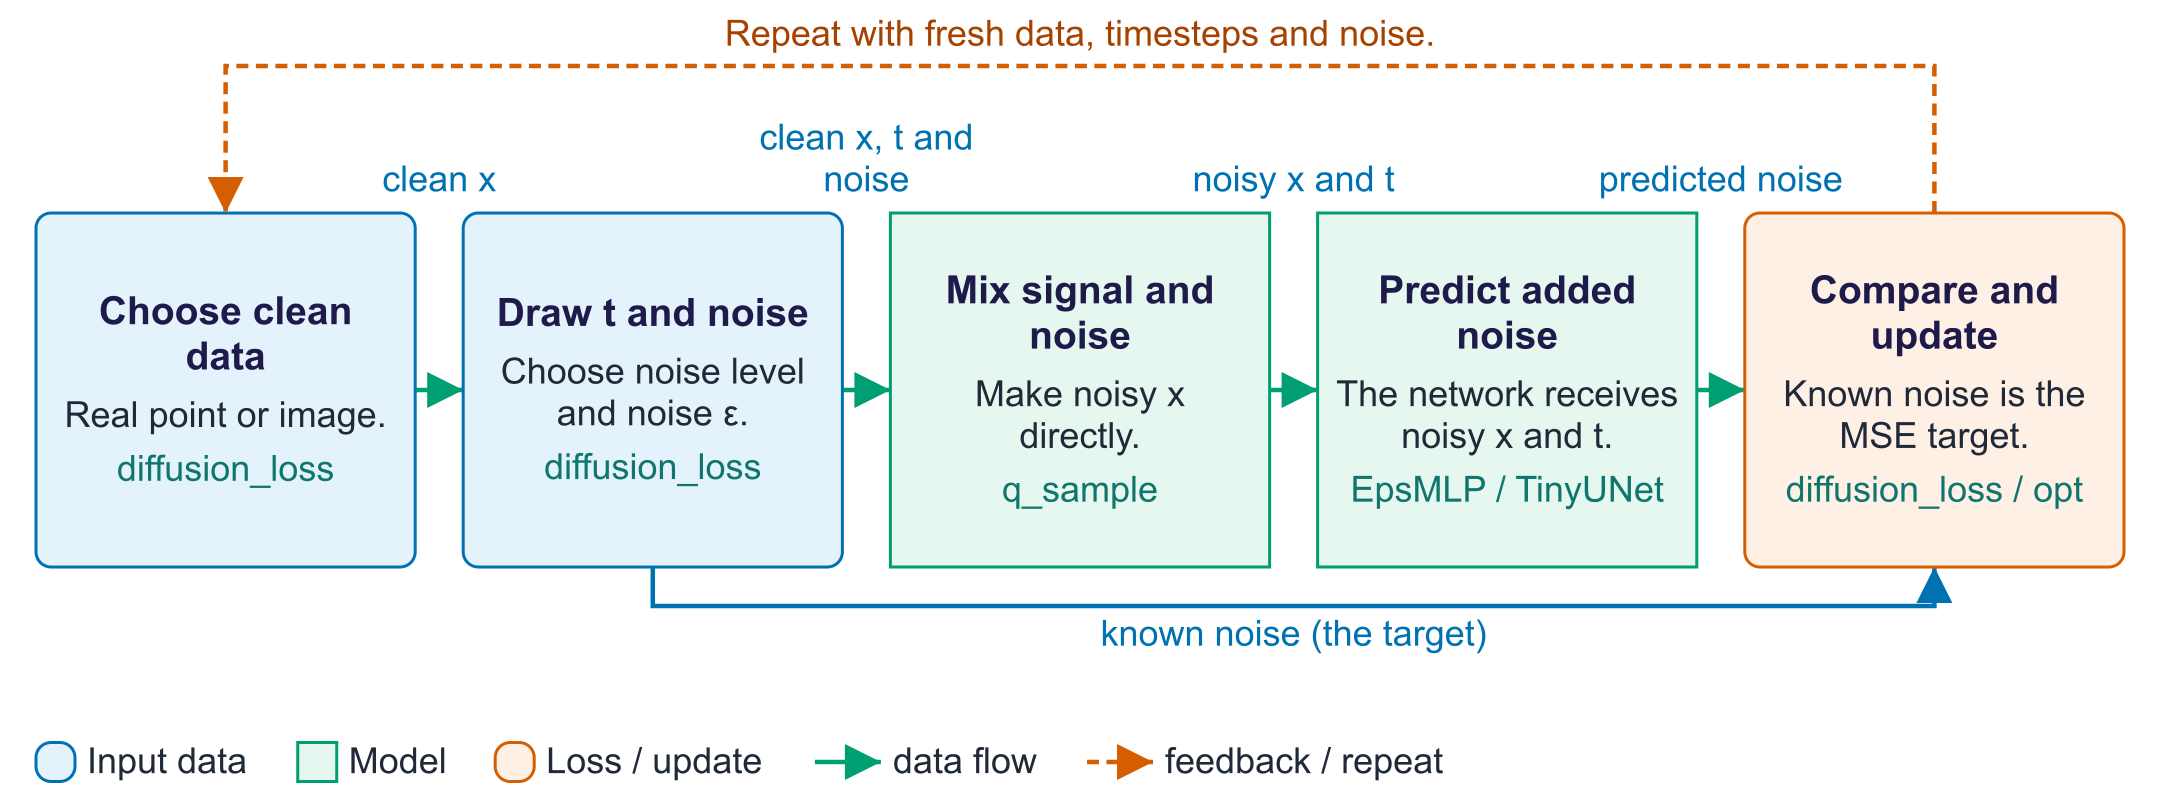

In [ ]:
from sklearn.datasets import make_swiss_roll

T2 = 200
b2 = torch.linspace(1e-4, 0.05, T2)
a2 = 1 - b2
ab2 = torch.cumprod(a2, 0)
data2d = torch.tensor(make_swiss_roll(20000, noise=0.4, random_state=0)[0][:, [0, 2]] / 10.0, dtype=torch.float32)


class EpsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(),
                                 nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 2))

    def forward(self, x, t):
        return self.net(torch.cat([x, (t.float() / T2).unsqueeze(1)], dim=1))


def diffusion_loss(model, x0, T_, abar_):
    # The model sees noisy data and t; the known noise follows the target path.
    t = torch.randint(0, T_, (x0.size(0),), device=x0.device)
    eps = torch.randn_like(x0)
    xt = q_sample(x0, t, eps, abar_)
    return F.mse_loss(model(xt, t), eps)


def reverse_step(model, x, t, betas_, alphas_, abar_):
    tt = torch.full((x.size(0),), t, device=x.device, dtype=torch.long)
    e = model(x, tt)
    mean = (x - betas_[t] / (1 - abar_[t]).sqrt() * e) / alphas_[t].sqrt()
    return mean + (betas_[t].sqrt() * torch.randn_like(x) if t > 0 else 0)


m2 = EpsMLP()
opt = torch.optim.Adam(m2.parameters(), lr=1e-3)
for step in range(500 if SMOKE else 6000):
    loss = diffusion_loss(m2, data2d[torch.randint(0, len(data2d), (512,))], T2, ab2)
    opt.zero_grad(); loss.backward(); opt.step()
print("final 2-D loss:", round(loss.item(), 4))

with torch.no_grad():
    x = torch.randn(2000, 2)
    shots = {}
    for t in reversed(range(T2)):
        x = reverse_step(m2, x, t, b2, a2, ab2)
        if t in (150, 50, 0):
            shots[t] = x.clone()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, t in zip(axes, (150, 50, 0)):
    ax.scatter(*data2d[:2000].T, s=1, color="lightgray")
    ax.scatter(*shots[t].T, s=1)
    ax.set_title(f"reverse step t = {t}"); ax.set_aspect("equal")
plt.show()

## Part A3 · A tiny U-Net DDPM on MNIST

The denoiser must output a tensor of the same shape as its input. A small **U-Net** (down-sample, up-sample, skip connections) with a **sinusoidal timestep embedding** does the job. Training uses exactly your `diffusion_loss`.
The embedding turns a timestep number into features. Skip connections pass
saved spatial information from the shrinking path to the expanding path.
They join features; they do not supply the clean training image to the model.

**Purpose:** Train and sample the tiny image U-Net.
**Why now:** One model receives all timestep values.
**Expected observation:** Recorded losses and a full DDPM sample row; poor samples are possible.

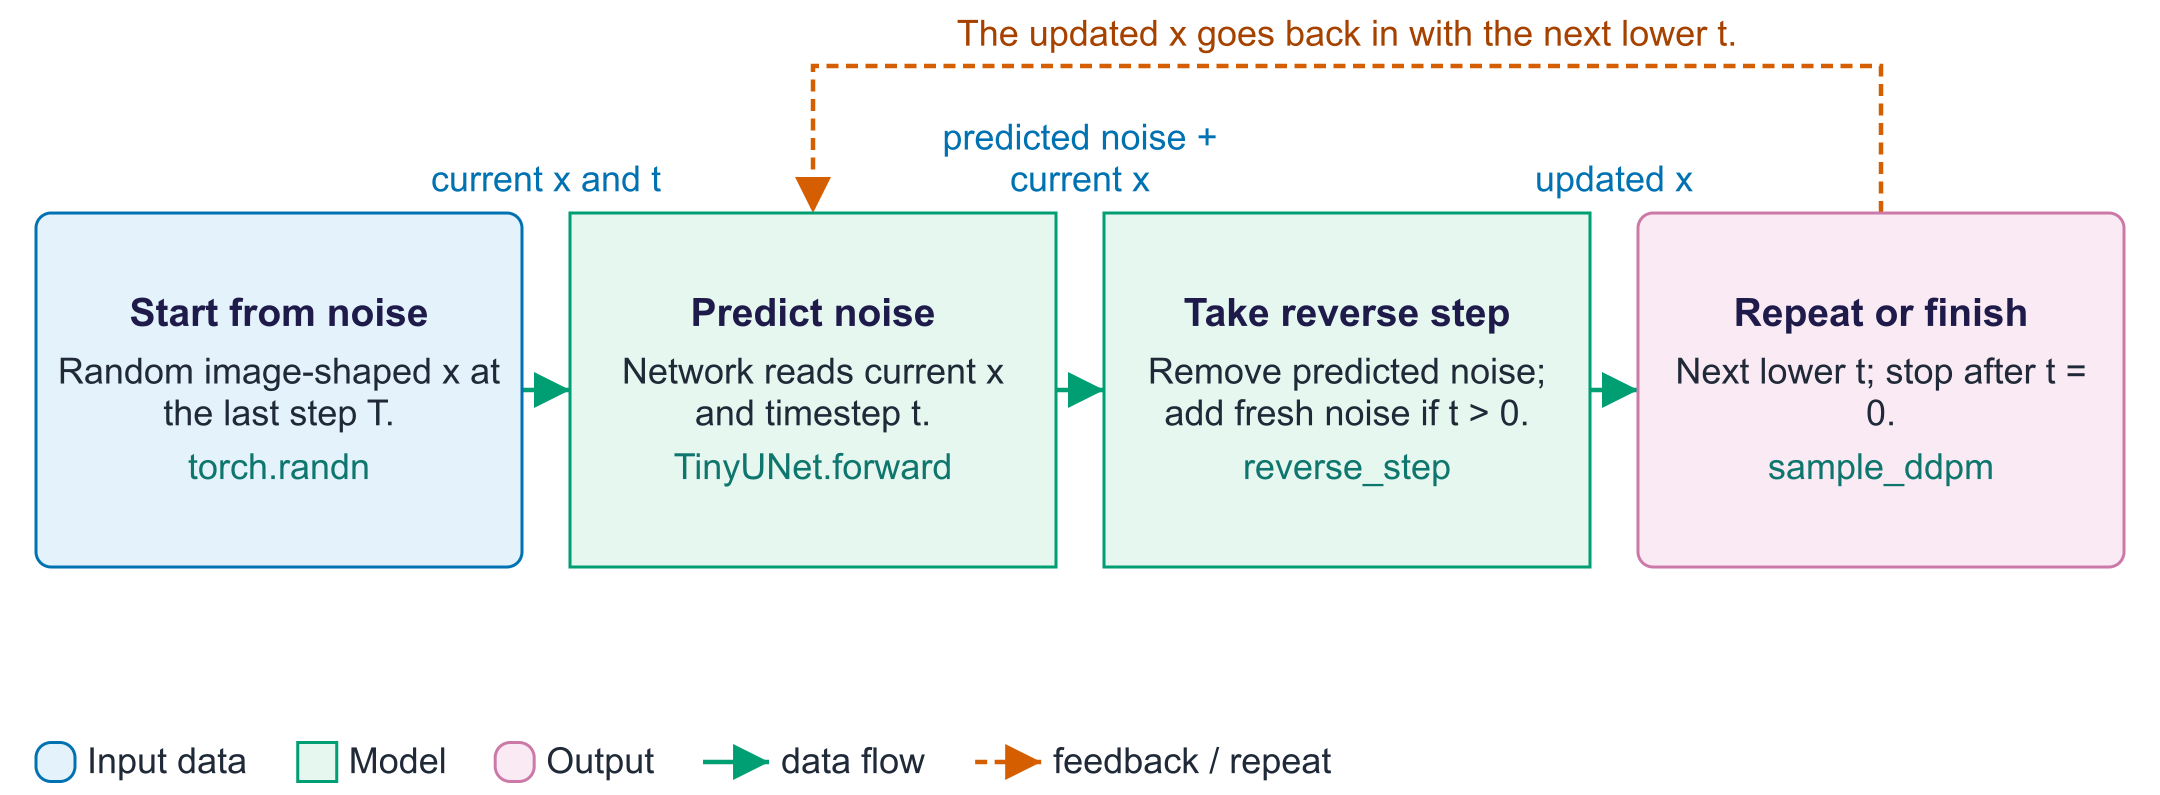

In [ ]:
def timestep_embedding(t, dim=64):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    ang = t.float()[:, None] * freqs[None]
    return torch.cat([ang.sin(), ang.cos()], dim=1)


class Block(nn.Module):
    def __init__(self, cin, cout, tdim=64):
        super().__init__()
        self.c1, self.c2 = nn.Conv2d(cin, cout, 3, padding=1), nn.Conv2d(cout, cout, 3, padding=1)
        self.n1, self.n2 = nn.GroupNorm(8, cout), nn.GroupNorm(8, cout)
        self.t = nn.Linear(tdim, cout)
        self.skip = nn.Conv2d(cin, cout, 1) if cin != cout else nn.Identity()

    def forward(self, x, te):
        h = F.silu(self.n1(self.c1(x))) + self.t(te)[:, :, None, None]
        return F.silu(self.n2(self.c2(h))) + self.skip(x)


class TinyUNet(nn.Module):
    def __init__(self, c=32):
        super().__init__()
        self.tmlp = nn.Sequential(nn.Linear(64, 64), nn.SiLU(), nn.Linear(64, 64))
        self.inc = nn.Conv2d(1, c, 3, padding=1)
        self.d1, self.d2, self.mid = Block(c, c), Block(c, 2 * c), Block(2 * c, 2 * c)
        self.u2, self.u1 = Block(4 * c, c), Block(2 * c, c)
        self.out = nn.Conv2d(c, 1, 3, padding=1)

    def forward(self, x, t):
        te = self.tmlp(timestep_embedding(t))
        h1 = self.d1(self.inc(x), te)                        # 28x28
        h2 = self.d2(F.avg_pool2d(h1, 2), te)                # 14x14
        m = self.mid(F.avg_pool2d(h2, 2), te)                # 7x7
        u = self.u2(torch.cat([F.interpolate(m, scale_factor=2), h2], 1), te)
        u = self.u1(torch.cat([F.interpolate(u, scale_factor=2), h1], 1), te)
        return self.out(u)


unet = TinyUNet().to(DEVICE)
print(f"TinyUNet: {sum(p.numel() for p in unet.parameters()):,} parameters")
train_subset = Subset(mnist, range(2000)) if SMOKE else mnist
dl = DataLoader(train_subset, batch_size=128, shuffle=True, drop_last=True)
opt = torch.optim.Adam(unet.parameters(), lr=2e-3)
EPOCHS = 1 if SMOKE else (6 if DEVICE == "cuda" else 2)
t0 = time.time()
for epoch in range(EPOCHS):
    for x, _ in dl:
        loss = diffusion_loss(unet, x.to(DEVICE), T, abar)
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"epoch {epoch + 1}: loss {loss.item():.4f}  ({time.time() - t0:.0f} s)")

betas_d, alphas_d, abar_d = betas.to(DEVICE), alphas.to(DEVICE), abar.to(DEVICE)


@torch.no_grad()
def sample_ddpm(model, n=16, steps=T):
    # Use the full T-step schedule here. Lowering steps only truncates this chain;
    # it does not make valid large jumps from index T-1. For skipping, use DDIM.
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=DEVICE)
    for t in reversed(range(steps)):
        x = reverse_step(model, x, t, betas_d, alphas_d, abar_d)
    return x.clamp(-1, 1).cpu()


def show_row(imgs, title):
    plt.figure(figsize=(12, 1.2)); plt.imshow(np.hstack(imgs[:, 0].numpy()), cmap="gray_r", vmin=-1, vmax=1)
    plt.axis("off"); plt.title(title, loc="left"); plt.show()


t0 = time.time()
ddpm_imgs = sample_ddpm(unet, n=8 if SMOKE else 16)
ddpm_time = time.time() - t0
show_row(ddpm_imgs, f"DDPM, 1000 steps ({ddpm_time:.1f} s)")

### A4 · A faster sampler: DDIM

DDIM (Song, Meng & Ermon, 2020) takes large **deterministic** steps along a sub-sequence of timesteps. From the noise prediction $\hat\epsilon$ at step $t$:

$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}}, \qquad x_{t'} = \sqrt{\bar\alpha_{t'}}\,\hat{x}_0 + \sqrt{1-\bar\alpha_{t'}}\,\hat\epsilon$$

where $t' < t$ is the next timestep in the sub-sequence. **TODO 4:** implement the DDIM update.
Unlike shortening the DDPM loop, `seq` spans index `T - 1` down to 0.
Each DDIM update explicitly uses both the current and next schedule values.
Read the two equations in order: first estimate the clean image, then mix
that estimate with the predicted noise at a lower noise level. The last step
uses `a_next=1`, so its remaining-noise coefficient is zero.

**Purpose:** Implement schedule-spanning DDIM.
**Why now:** Compatible larger jumps reduce calls without retraining.
**Expected observation:** 50 selected levels and measured time; quality may change.

In [ ]:
@torch.no_grad()
def sample_ddim(model, n=16, steps=50):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=DEVICE)
    seq = torch.linspace(T - 1, 0, steps).long().tolist()
    for i, t in enumerate(seq):
        t_next = seq[i + 1] if i + 1 < len(seq) else -1
        eps = model(x, torch.full((n,), t, device=DEVICE, dtype=torch.long))
        a_t = abar_d[t]
        a_next = abar_d[t_next] if t_next >= 0 else torch.tensor(1.0, device=DEVICE)
        x0_hat = (x - (1 - a_t).sqrt() * eps) / a_t.sqrt()
        x = a_next.sqrt() * x0_hat + (1 - a_next).sqrt() * eps
    return x.clamp(-1, 1).cpu()


t0 = time.time()
ddim_imgs = sample_ddim(unet, n=8 if SMOKE else 16, steps=50)
show_row(ddim_imgs, f"DDIM, 50 steps ({time.time() - t0:.1f} s)")

✍️ **Question 1.** Compare DDPM (1000 steps) with DDIM (50 steps): quality and time. Why can DDIM skip steps without retraining the network?

**✅ Model answer:**
The comparison uses 50 versus 1000 network calls, so DDIM should require much less sampling work; measure actual time and describe the quality you observe rather than assuming a 20× wall-clock gain. This DDIM implementation is deterministic given its starting noise and fixed model; DDPM injects fresh noise at intermediate reverse steps. DDIM does not need retraining because it uses the same trained noise predictor at selected noise levels. Its prediction also gives an estimate of the clean image x̂₀. DDIM combines x̂₀ and ε̂ with the next timestep's coefficients to jump to that lower noise level. The sampling procedure changes, not the trained weights. Simply setting sample_ddpm(steps=50) would instead truncate the chain and would not implement these jumps.

## Part B · Stable Diffusion with Hugging Face Diffusers

A `DiffusionPipeline` bundles the **text encoder**, the **denoiser** (U-Net), the **VAE** and a **scheduler** (sampler). On a T4 GPU we load it in half precision (float16).
This lab selects the CPU fallback when the GPU has less than 8 GB memory.
That also avoids the half-precision image failures reported on older GTX 16-series cards.
To request CPU explicitly, set `os.environ["GENAI_FORCE_CPU"] = "1"` before the setup cell.
CPU uses float32 and SD-Turbo; its controls differ from the SD 1.5 GPU experiment below.
The text encoder supplies prompt features. The denoiser operates on a
compressed image representation, and the VAE decoder turns the final
representation into pixels. **Float16** stores each floating-point value
with 16 bits; it can reduce memory use on supported hardware.

**Purpose:** Load and inspect the active image pipeline.
**Why now:** The pretrained system adds text encoding and latent decoding.
**Expected observation:** Actual model path, scheduler and component sizes.

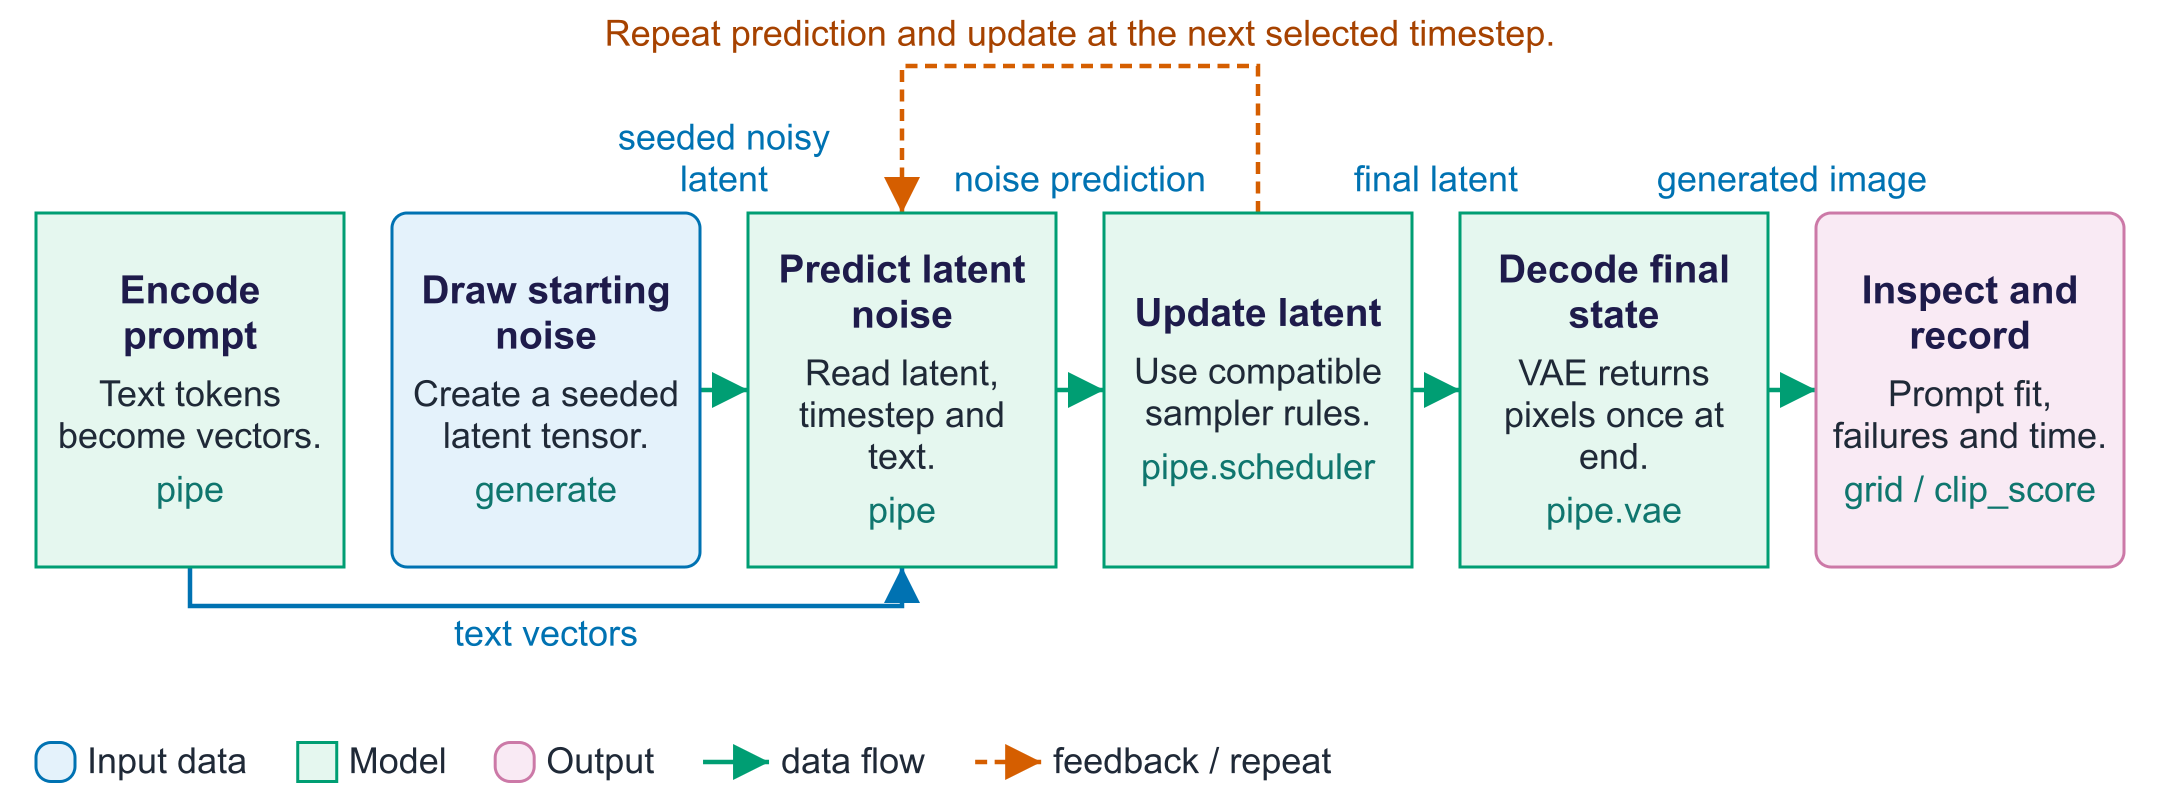

In [ ]:
from diffusers import AutoPipelineForText2Image, DPMSolverMultistepScheduler, EulerAncestralDiscreteScheduler, StableDiffusionPipeline

USE_SD15 = DEVICE == "cuda" and not SMOKE
dtype = torch.float16 if DEVICE == "cuda" else torch.float32
if SMOKE:
    pipe = StableDiffusionPipeline.from_pretrained("hf-internal-testing/tiny-sd-pipe", safety_checker=None)
    SIZE, STEPS = 64, 3
elif USE_SD15:
    pipe = StableDiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=dtype)
    SIZE, STEPS = 512, 25
else:
    print("No GPU: using the distilled SD-Turbo model (1-2 steps) for Part B.")
    pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=dtype)
    SIZE, STEPS = 512, 2
pipe = pipe.to(DEVICE)
pipe.set_progress_bar_config(disable=True)
print(type(pipe).__name__, "| scheduler:", type(pipe.scheduler).__name__)
for name in ("text_encoder", "unet", "vae"):
    mod = getattr(pipe, name)
    print(f"  {name:12s} {sum(p.numel() for p in mod.parameters()) / 1e6:7.1f} M parameters")


def generate(prompt, seed=42, steps=STEPS, guidance=7.5, negative=None):
    # This is inference through pretrained components; it performs no training.
    g = torch.Generator(device="cpu").manual_seed(seed)
    if not USE_SD15 and not SMOKE:
        guidance = 0.0  # SD-Turbo is trained without classifier-free guidance
    return pipe(prompt, negative_prompt=negative, num_inference_steps=steps, guidance_scale=guidance,
                generator=g, height=SIZE, width=SIZE).images[0]


def grid(images, titles, size=3):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size + 0.4))
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im); ax.set_title(t); ax.axis("off")
    plt.show()


PROMPT = "a watercolour painting of a lighthouse on a cliff at sunset, seagulls, soft light"
t0 = time.time()
img = generate(PROMPT)
print(f"one image in {time.time() - t0:.1f} s")
plt.imshow(img); plt.axis("off"); plt.show()

### B1 · Sweep the controls
Change **one thing at a time** and keep the seed fixed. (On the SD-Turbo fallback, guidance is ignored.)

**Purpose:** Sweep one setting at a time.
**Why now:** Control comparisons require a fixed seed and prompt.
**Expected observation:** Step/guidance/seed grids; Turbo guidance is disabled.

In [ ]:
step_values = [2, 5, 10, 25] if USE_SD15 else [1, 2, 3, 4]
grid([generate(PROMPT, steps=s) for s in step_values], [f"{s} steps" for s in step_values])
if USE_SD15 or SMOKE:
    guidance_values = [1.0, 3.0, 7.5, 15.0]
    guidance_images = [generate(PROMPT, guidance=g) for g in guidance_values]
    grid(guidance_images, [f"guidance {g}" for g in guidance_values])
grid([generate(PROMPT, seed=s) for s in (1, 2, 3, 4)], [f"seed {s}" for s in (1, 2, 3, 4)])

### B2 · Negative prompts and schedulers

**TODO 5:** generate the reading-corner prompt twice with the same seed: once normally, once with a negative prompt of your choice (e.g. remove an object or "blurry, low quality"). Then swap the scheduler to `EulerAncestralDiscreteScheduler` and regenerate.
**Check the active model first:** this negative-prompt experiment is useful
with SD 1.5's guidance. The SD-Turbo fallback sets guidance to zero, so a
negative prompt is not an effective control there. Record that limitation
instead of interpreting unchanged output as evidence about negative prompts.

**Purpose:** Test guidance references and samplers.
**Why now:** A negative prompt depends on active guidance.
**Expected observation:** Two prompt variants and two schedulers; unchanged Turbo negatives are expected.

In [ ]:
P2 = "a cosy reading corner with a green armchair and a lamp, photograph"
a = generate(P2, seed=7)
b = generate(P2, seed=7, negative="lamp, blurry, low quality")
grid([a, b], ["no negative prompt", "with negative prompt"], size=4)

original_scheduler = pipe.scheduler
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
c = generate(P2, seed=7)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(original_scheduler.config)
d = generate(P2, seed=7)
pipe.scheduler = original_scheduler
grid([c, d], ["Euler ancestral scheduler", "DPM-Solver++ scheduler"], size=4)

### B3 · A distilled few-step model: SD-Turbo
Compare generation time with the 25-step, guided Stable Diffusion run above.

**Purpose:** Optionally compare a distilled model.
**Why now:** A shorter trained student can reduce denoiser calls.
**Expected observation:** Turbo times and images when a full SD 1.5 run is active.

In [ ]:
if USE_SD15:
    turbo = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=dtype).to(DEVICE)
    turbo.set_progress_bar_config(disable=True)
    for s in (1, 4):
        t0 = time.time()
        im = turbo(PROMPT, num_inference_steps=s, guidance_scale=0.0, generator=torch.Generator("cpu").manual_seed(42)).images[0]
        print(f"SD-Turbo {s} step(s): {time.time() - t0:.2f} s")
        plt.imshow(im); plt.axis("off"); plt.title(f"SD-Turbo, {s} step(s)"); plt.show()
    del turbo
    torch.cuda.empty_cache()
else:
    print("Skipped (already using SD-Turbo, or smoke test).")

## Part C · Evaluating prompt alignment with a CLIP score

CLIP (week 9) embeds images and texts in the same space. The **CLIP score** is the cosine similarity between an image embedding and its prompt's embedding (often ×100). **TODO 6:** compute the cosine similarity from the two embedding tensors.

**Purpose:** Evaluate prompt-image embeddings.
**Why now:** CLIP similarity tests one aspect of alignment.
**Expected observation:** Scores and unrelated-prompt control; inspect counts and layout yourself.

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


@torch.no_grad()
def clip_score(image, text):
    # This checks similarity in CLIP's feature space, not every visible detail.
    inputs = proc(text=[text], images=image, return_tensors="pt", padding=True).to(DEVICE)
    out = clip(**inputs)  # projected embeddings; works with transformers v4 and v5
    img_emb, txt_emb = out.image_embeds, out.text_embeds
    return F.cosine_similarity(img_emb, txt_emb).item()


rows = []
if USE_SD15 or SMOKE:
    for gscale, im in zip(guidance_values, guidance_images):
        rows.append((f"guidance {gscale}", clip_score(im, PROMPT)))
rows.append(("unrelated prompt (control)", clip_score(img, "a plate of spaghetti on a kitchen table")))
for name, s in rows:
    print(f"{name:28s} CLIP score = {100 * s:5.1f}")

✍️ **Question 2.** How does the CLIP score change with guidance? Does the highest score correspond to the image you find best? Give two limitations of CLIP score as an evaluation metric.

**✅ Model answer:**
Describe your actual scores and pictures. Guidance can affect alignment and artefacts, but no ordering is guaranteed; the unrelated-prompt control is a check of this experiment. The highest score is not always the image a person prefers: very high guidance can score well while looking over-saturated. Limitations: (1) CLIP measures semantic similarity in its own embedding space and can be fooled by images containing the right keywords or text, while ignoring counting, spatial relations or attribute binding (e.g. "red cube on a blue sphere"); (2) it says nothing about realism, artefacts, diversity or safety, and it inherits CLIP's biases and English-centric training. Evaluation should combine it with FID/realism metrics and human judgement using a rubric.

✍️ **Question 3.** Your project team wants to generate marketing images with Stable Diffusion. List three settings you would record for reproducibility and two responsible-use checks.

**✅ Model answer:**
Reproducibility: model name and version (e.g. stable-diffusion-v1-5), scheduler, number of steps, guidance scale, seed, image size, negative prompt, library versions and hardware. Responsible use: (1) check the model licence and the organisation's policy for commercial use and avoid generating identifiable people, trademarks or artists' styles without permission; (2) review outputs for bias and harmful content (audit prompts across demographics), keep the safety checker on, and label images as AI-generated (content credentials / EU AI Act Art. 50 disclosure where relevant).

## Optional extension · From DDPM to flow matching

Adapt both the training target and the time input: the 2-D EpsMLP divides integer t by T2, so either pass continuous t × T2 into it or change its time normalisation to accept t in [0, 1].
Replace the training target: with $x_t = (1-t)\,x_0 + t\,\epsilon$ for $t \in [0,1]$, train the network to predict the velocity $v = \epsilon - x_0$, then sample by Euler integration from $t=1$ to $t=0$: $x \leftarrow x - \Delta t \cdot v_\theta(x, t)$. Try it on the 2-D swiss roll with 20 Euler steps.

| Experiment | Setting | Measure | Result | Interpretation |
|---|---|---|---|---|
| MNIST DDPM | 1000 vs 50 DDIM steps | time, visual quality | | |
| Active image model | guidance sweep if supported; otherwise seed sweep | CLIP similarity, visual | | |
| SD-Turbo vs SD 1.5 | 1–4 vs 25 steps | seconds per image | | |

**Before next week:** watch 3Blue1Brown's *Transformers* and *Attention in transformers* (chapters 5–6).

## Week 4: what we learned

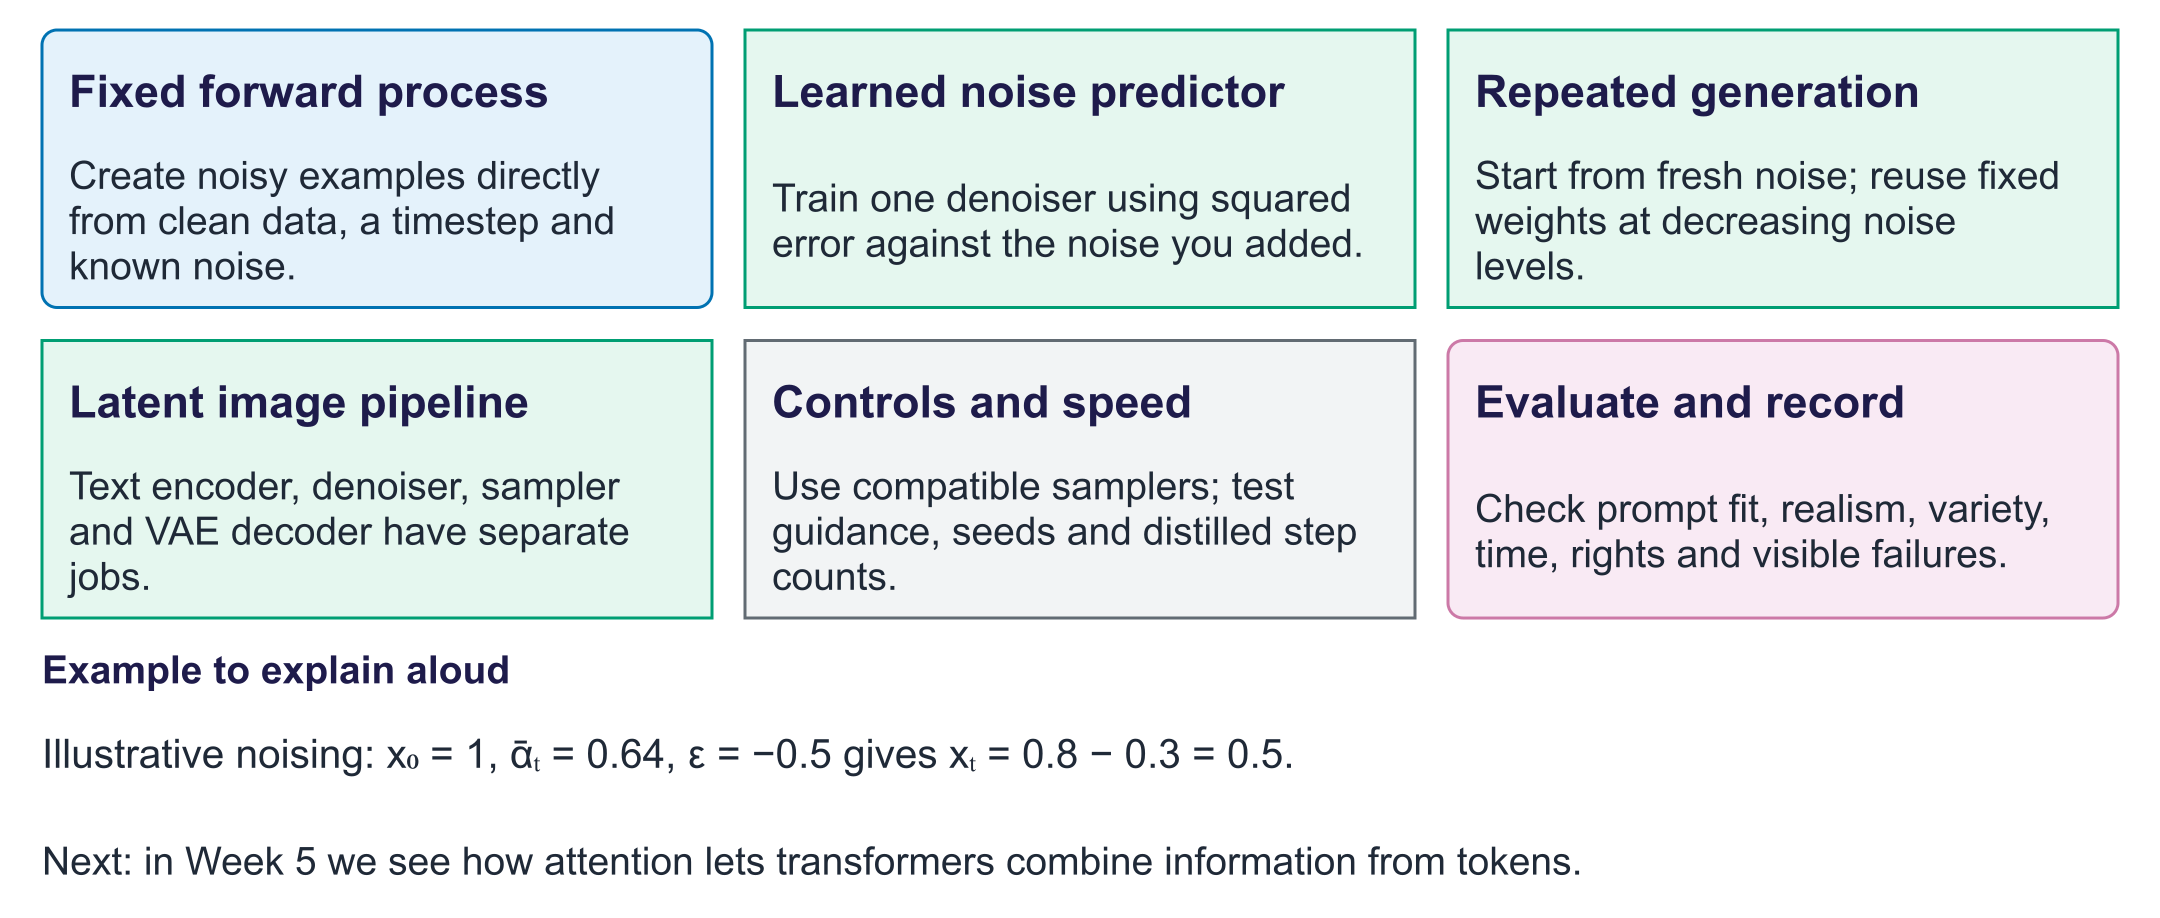

Illustrative noising: x₀ = 1, ᾱₜ = 0.64, ε = −0.5 gives xₜ = 0.8 − 0.3 = 0.5.

**Explain without looking:** Does 50-step DDIM require 50 separately trained denoisers?

**Instructor answer:** No. One denoiser is reused at 50 selected noise levels; the sampling rule changes.